# Setup

In [64]:
from pycose.messages.sign1message import Sign1Message
from qr_manager import sign_message, verify_message, encrypt_message, decrypt_message
from datetime import datetime
from PIL import Image
from pprint import pprint
from io import BytesIO
from pyzbar import pyzbar
import cbor2, zlib, base45, qrcode

## Generate Legitimate QR

In [2]:
# User Information
_img_path = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\residents\sample\face_compressed.jpg"

with open(_img_path, "rb") as file:
    image_bytes = file.read()

claim_169 = {
    1 : "6149804723",
    16 : image_bytes,
    17 : 1,
    99 : 4
}

cbor_claim_169  = cbor2.dumps(claim_169)

info = {
    1 : "DCS",
    2 : datetime.now().timestamp(),
    169 : cbor_claim_169
}

cbor_info = cbor2.dumps(info)

pprint(claim_169)
print()
pprint(info)

{1: '6149804723',
 16: b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00'
     b'\xff\xdb\x00C\x00P7<F<2PFAFZUP_x\xc8\x82xnnx\xf5\xaf\xb9\x91\xc8\xff'
     b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
     b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
     b'\xff\xff\xff\xff\xff\xff\xc0\x00\x0b\x08\x00-\x00-\x01\x01'
     b'\x11\x00\xff\xc4\x00\x19\x00\x00\x03\x01\x01\x01\x00\x00\x00\x00'
     b'\x00\x00\x00\x00\x00\x00\x00\x02\x03\x04\x00\x01\x05\xff\xc4\x00'
     b'\x1f\x10\x00\x02\x02\x02\x03\x00\x03\x00\x00\x00\x00\x00\x00\x00'
     b'\x00\x00\x01\x11\x00\x02\x03!\x121A\x042Q\xff\xda\x00\x08\x01\x01'
     b'\x00\x00?\x00*\x01La\xce\x1b\xd4\xfb9\x06\xd6\x03\xb3\x07\x98>'
     b'\xc5\xde\xa7\x91\x96\xdc\x04\xd3\x93\xe4\x1cl\xb8\x88f\xab\x181H&'
     b"\x99\x82\x83\xea0\x15)\xf1\xc05\x06\xcc\xcd\x93\xea\xa2P3 '"
     b'\x0c\xac\xe8\xa8\x04"\xe2\xeeI\x04>\xe2\xc1\xfd\x98\x98\xdc\x18\x86@'
     b'[\xd4\xa3 \xdb\x89\xb06\x

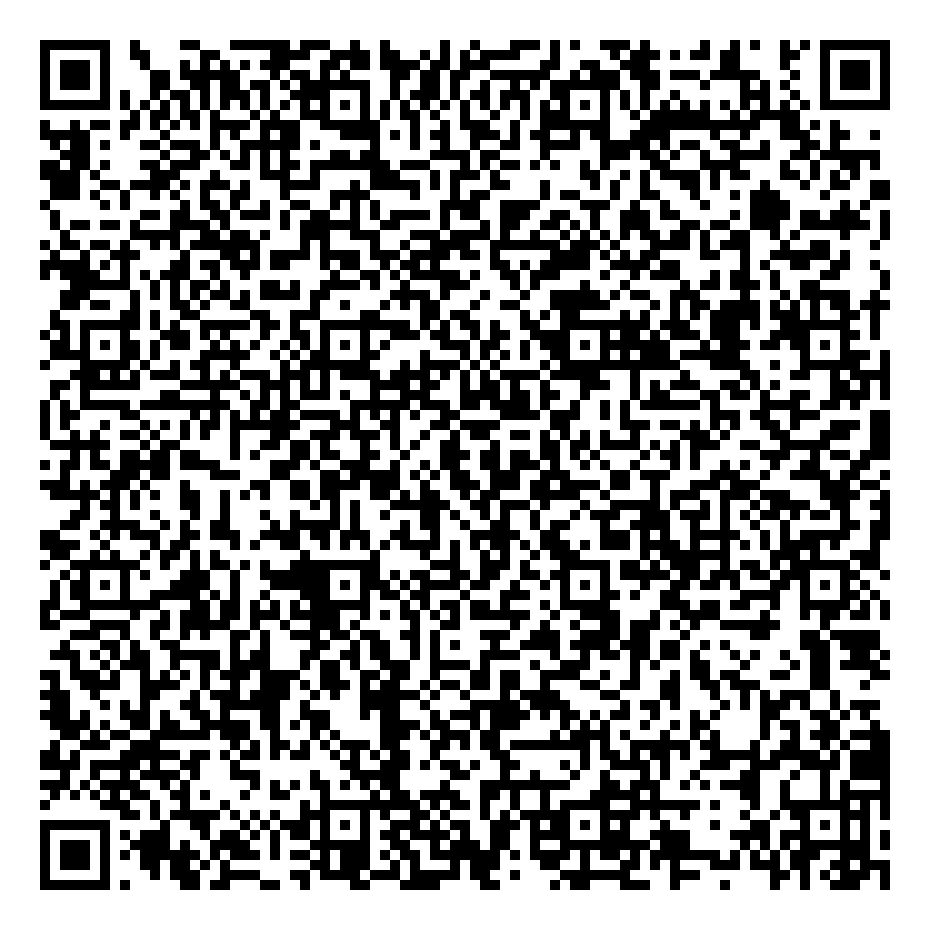

In [9]:
# Generate QR
s_msg = sign_message(cbor_info)

e_msg = encrypt_message(s_msg)

c_msg = zlib.compress(e_msg)

b45_msg = base45.b45encode(c_msg).decode()

qr = qrcode.make(b45_msg)

buffer = BytesIO()
qr.save(buffer, format="JPEG")
buffer.seek(0)

qr

## Generate Tampered QR

In [58]:
img_path = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\qr_manager\sample\QR_1.png"
img = Image.open(img_path)

decoded_text = pyzbar.decode(img)[0].data.decode('utf-8')
decoded_b45 = base45.b45decode(decoded_text)
decoded_b45

b'x\x9c\x01\xc0\x01?\xfe\x7f\xb7~\xbb\xcfnh\xb5\xef\x0b\xc3\xab\x7f&"\x8d.a\xcf$\xca\xbbvQ\xc1\x83q\xe2\x06p\xa4\xd2\x85\x8e\x8a\xeb@\x1dsH\x9b\xe48\x96\xa7\xdcD5\x12\xfb\x0c\xd9q>\xcbN-V\xd2\x12A_-\xa5Qp\xbe\xd1\x02\xf8\x8c(G\xcb`}\xe9A\xc7A\x906\x1b\x02\xae_\xc13\xf2\x80r\xc1\xf0\x99\xafY\xe2\xa2\x95\xe0\x17\xa7\xe1}\xa0\'\x9f\x184\xa0\xd4\x0c<\x1c^\xab8zS2;*\x9fTu\x00\xf6\x1e\xed\x11(\xff\x7f\x8d\x1e\x8c\x19!\xe7\xec\xaba2\xb0\xf6\xbb\xb7b\x97\x91\xd9\xc2\xe6\xbf\xcc\xf0z\xdb\x05v\xf1\x9d\x1f\xe7K\x84<\x81\x9d\x16\xa5\xadS\xe1\x1few\x95\x10en\t\x8d\xd4\xb39\xca\xa9\xfdw~M`P\\\x19\xab\xebT\xe4U\x02>\x1a(+\xbc]\x18\xfe\x02\xfc\xa0w<!$\xe1\x07p\x1c\x9b\x08\xe9Y\xd8\xbf\xbf\xbe\xf85\xed(\x8f\x87\xb3J\'\\#\xfa\xd0\xa7\x06&e}\xb6\xc49\xf6\xc1\xd7r\x94?\x95g\xb4\x1e`\xaa\xe1\xad\x97=\xe5\xba2\xdbI\x8e\x94\x8f-M\x172S\x9bJ\x88\xa25\xfd\xd4\x87X\x88\xad\x83\xc9\x925\xa7xH\xc5E`\xffq\xc6\xfer\xc7[\xdb\x83>\xb8q\xff\x7f\x1f\x8fm5\xbed~9\xd5\x01We?\xc9\xef3\xdd\xc0\x8e\xa6\xc3\xd6\xac\x93#\xd1X

### Changing a byte in QR.

In [51]:
mutable = bytearray(decoded_b45)
mutable[0] ^= 0x01
tampered_bytes = bytes(mutable)
tampered_bytes

b'y\x9c\x01\xc0\x01?\xfe\x7f\xb7~\xbb\xcfnh\xb5\xef\x0b\xc3\xab\x7f&"\x8d.a\xcf$\xca\xbbvQ\xc1\x83q\xe2\x06p\xa4\xd2\x85\x8e\x8a\xeb@\x1dsH\x9b\xe48\x96\xa7\xdcD5\x12\xfb\x0c\xd9q>\xcbN-V\xd2\x12A_-\xa5Qp\xbe\xd1\x02\xf8\x8c(G\xcb`}\xe9A\xc7A\x906\x1b\x02\xae_\xc13\xf2\x80r\xc1\xf0\x99\xafY\xe2\xa2\x95\xe0\x17\xa7\xe1}\xa0\'\x9f\x184\xa0\xd4\x0c<\x1c^\xab8zS2;*\x9fTu\x00\xf6\x1e\xed\x11(\xff\x7f\x8d\x1e\x8c\x19!\xe7\xec\xaba2\xb0\xf6\xbb\xb7b\x97\x91\xd9\xc2\xe6\xbf\xcc\xf0z\xdb\x05v\xf1\x9d\x1f\xe7K\x84<\x81\x9d\x16\xa5\xadS\xe1\x1few\x95\x10en\t\x8d\xd4\xb39\xca\xa9\xfdw~M`P\\\x19\xab\xebT\xe4U\x02>\x1a(+\xbc]\x18\xfe\x02\xfc\xa0w<!$\xe1\x07p\x1c\x9b\x08\xe9Y\xd8\xbf\xbf\xbe\xf85\xed(\x8f\x87\xb3J\'\\#\xfa\xd0\xa7\x06&e}\xb6\xc49\xf6\xc1\xd7r\x94?\x95g\xb4\x1e`\xaa\xe1\xad\x97=\xe5\xba2\xdbI\x8e\x94\x8f-M\x172S\x9bJ\x88\xa25\xfd\xd4\x87X\x88\xad\x83\xc9\x925\xa7xH\xc5E`\xffq\xc6\xfer\xc7[\xdb\x83>\xb8q\xff\x7f\x1f\x8fm5\xbed~9\xd5\x01We?\xc9\xef3\xdd\xc0\x8e\xa6\xc3\xd6\xac\x93#\xd1X

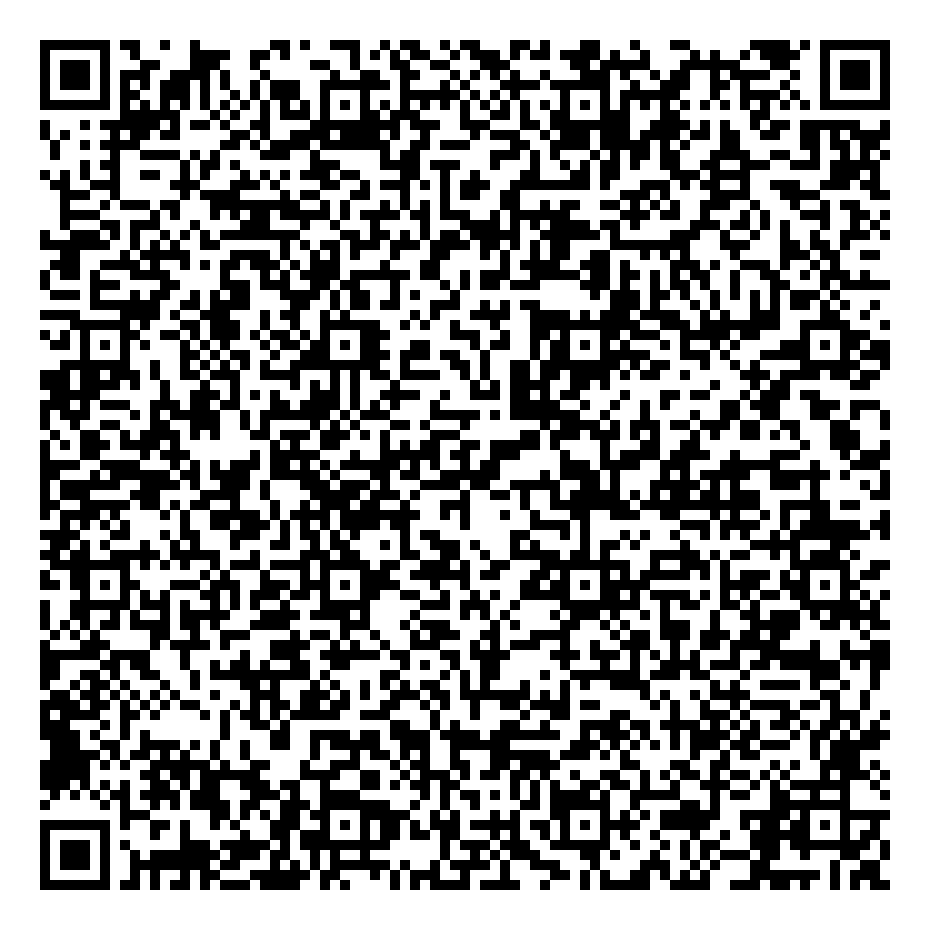

In [52]:
qr = qrcode.make(tampered_bytes)

buffer = BytesIO()
qr.save(buffer, format="JPEG")
buffer.seek(0)

qr

### Tampering QR

In [ ]:
decoded_text = pyzbar.decode(img)[0].data.decode('utf-8')
decoded_b45 = base45.b45decode(decoded_text)
uncompressed = zlib.decompress(decoded_b45)
d_msg = decrypt_message(uncompressed)
s_msg = verify_message(d_msg)

# sign1_msg = Sign1Message.decode(s_msg)
# payload = cbor2.loads(sign1_msg.payload)

# cbor_bytes = cbor2.dumps(payload)
# sign1_msg.payload = cbor_bytes
# tampered = sign1_msg.encode(sign=False)

# compress = zlib.compress(tampered)
# new_b45 = base45.b45encode(compress)

# qrcode.make(new_b45)

AttributeError: Message was not tagged.

In [62]:
cbor_s_msg[1] = "PH"

## Reading QR

{1: 'DCS',
 2: 1774242708.77429,
 169: b'\xa4\x01j6149804723\x10Y\x01-\xff\xd8\xff\xe0\x00\x10JFIF\x00'
      b'\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00P7<F<2PFAFZUP_'
      b'x\xc8\x82xnnx\xf5\xaf\xb9\x91\xc8\xff\xff\xff\xff\xff\xff\xff\xff'
      b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
      b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xc0'
      b'\x00\x0b\x08\x00-\x00-\x01\x01\x11\x00\xff\xc4\x00\x19\x00'
      b'\x00\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
      b'\x02\x03\x04\x00\x01\x05\xff\xc4\x00\x1f\x10\x00\x02\x02\x02\x03'
      b'\x00\x03\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x11\x00\x02\x03!\x121A'
      b'\x042Q\xff\xda\x00\x08\x01\x01\x00\x00?\x00*\x01La\xce\x1b\xd4'
      b'\xfb9\x06\xd6\x03\xb3\x07\x98>\xc5\xde\xa7\x91\x96\xdc\x04'
      b'\xd3\x93\xe4\x1cl\xb8\x88f\xab\x181H&\x99\x82\x83\xea0\x15)'
      b'\xf1\xc05\x06\xcc\xcd\x93\xea\xa2P3 \'\x0c\xac\xe8\xa8\x04"\xe2'
      b'\xeeI\x04

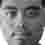

In [41]:
# Check signature
img_path = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\qr_manager\sample\QR_1.png"
img = Image.open(img_path)

decoded_text = pyzbar.decode(img)[0].data.decode('utf-8')
decoded_b45 = base45.b45decode(decoded_text)
uncompressed = zlib.decompress(decoded_b45)
d_msg = decrypt_message(uncompressed)
s_msg = verify_message(d_msg)
cbor_s_msg = cbor2.loads(s_msg)
pprint(cbor_s_msg)
cbor_claim_169 = cbor2.loads(cbor_s_msg[169])
print()
pprint(cbor_claim_169)
img = Image.open(BytesIO(cbor_claim_169[16]))
img

# Test Cases

## CASE 1: Legitimate QR
QR verification passes, and resident exist in the database

{1: 'DCS',
 2: 1774242708.77429,
 169: b'\xa4\x01j6149804723\x10Y\x01-\xff\xd8\xff\xe0\x00\x10JFIF\x00'
      b'\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00P7<F<2PFAFZUP_'
      b'x\xc8\x82xnnx\xf5\xaf\xb9\x91\xc8\xff\xff\xff\xff\xff\xff\xff\xff'
      b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff'
      b'\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xff\xc0'
      b'\x00\x0b\x08\x00-\x00-\x01\x01\x11\x00\xff\xc4\x00\x19\x00'
      b'\x00\x03\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00'
      b'\x02\x03\x04\x00\x01\x05\xff\xc4\x00\x1f\x10\x00\x02\x02\x02\x03'
      b'\x00\x03\x00\x00\x00\x00\x00\x00\x00\x00\x00\x01\x11\x00\x02\x03!\x121A'
      b'\x042Q\xff\xda\x00\x08\x01\x01\x00\x00?\x00*\x01La\xce\x1b\xd4'
      b'\xfb9\x06\xd6\x03\xb3\x07\x98>\xc5\xde\xa7\x91\x96\xdc\x04'
      b'\xd3\x93\xe4\x1cl\xb8\x88f\xab\x181H&\x99\x82\x83\xea0\x15)'
      b'\xf1\xc05\x06\xcc\xcd\x93\xea\xa2P3 \'\x0c\xac\xe8\xa8\x04"\xe2'
      b'\xeeI\x04

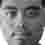

In [42]:
# Case 1
img_path = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\qr_manager\sample\QR_1.png"
img = Image.open(img_path)

decoded_text = pyzbar.decode(img)[0].data.decode('utf-8')
decoded_b45 = base45.b45decode(decoded_text)
uncompressed = zlib.decompress(decoded_b45)
d_msg = decrypt_message(uncompressed)
s_msg = verify_message(d_msg)
cbor_s_msg = cbor2.loads(s_msg)
pprint(cbor_s_msg)
cbor_claim_169 = cbor2.loads(cbor_s_msg[169])
print()
pprint(cbor_claim_169)
img = Image.open(BytesIO(cbor_claim_169[16]))
img

## CASE 2: QR Spoofing
QR verification passes, but resident fails the OIC face verification

## CASE 3: Tampered QR
QR verification fails because the signature does not match the payload

### Byte Flip

In [53]:
# Case 3
img_path = r"C:\Users\J4M3S\Desktop\MOSIP\customizeable-lgu-id\qr_manager\sample\QR_3_byteflip.png"
img = Image.open(img_path)

decoded_text = pyzbar.decode(img)[0].data.decode('utf-8')
decoded_b45 = base45.b45decode(decoded_text)
uncompressed = zlib.decompress(decoded_b45)
d_msg = decrypt_message(uncompressed)
s_msg = verify_message(d_msg)
cbor_s_msg = cbor2.loads(s_msg)
pprint(cbor_s_msg)
cbor_claim_169 = cbor2.loads(cbor_s_msg[169])
print()
pprint(cbor_claim_169)
img = Image.open(BytesIO(cbor_claim_169[16]))
img

ValueError: Invalid base45 string

## CASE 4: Legitimate PhilSys/MOSIP QR
QR cannot be verified, but MOSIP Authentication passes and resident exists in the database

## CASE 5: Legitimate QR but not in Database
MOSIP Authentication passes, but resident is not registered in the database

## CASE 6: Invalid QR
QR not generated by the LGU